In [1]:
import numpy as np
import matplotlib.image as img
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Convolution

In [2]:
def convolution2d(image, kernel):
    m, n = kernel.shape
    if m == n:
        y, x = image.shape
        y = y - m + 1
        x = x - m + 1
        new_image = np.zeros((y, x))
        for i in range(y):
            for j in range(x):
                new_image[i][j] = np.sum(image[i:i+m, j:j+m] * kernel)
    return new_image.astype(np.uint8)

# MSE

In [3]:
def calculate_mse(img_python, img_sv):    
    min_shape = (min(img_python.shape[0], img_sv.shape[0]), min(img_python.shape[1], img_sv.shape[1]))
    squared_diff = (img_python[:min_shape[0], :min_shape[1]] - img_sv[:min_shape[0], :min_shape[1]]) ** 2
    return np.mean(squared_diff)

# Main

In [38]:
img = Image.open("lena.bmp")

img = np.array(img, dtype=np.uint8)
if len(img.shape) == 3: 
    img = np.mean(image, axis=2)
height, width = img.shape

with open("C:/vivado_projects/test/conv/conv.sim/sim_1/behav/xsim/test.ppm", "w") as f:
    f.write("P2\n")
    f.write("# Generated\n")
    f.write(f"{width} {height}\n")
    f.write("255\n")

    for y in range(height):
        for x in range(width):
            f.write(f"{img[y, x]} ")
        f.write("\n")


In [5]:
# result = np.pad(img, pad_width=1, mode='constant', constant_values=0)

kernel = 1/16 * np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
])

# kernel = np.array([
#     [-1, -1, -1],
#     [-1, 9, -1],
#     [-1, -1, -1]
# ])

# kernel = np.array([
#     [0,1,0],
#     [1,-4,1],
#     [0,1,0]
# ])

img =  np.array([
    [1, 2, 3, 4, 5],
    [6, 7, 8, 9, 10],
    [11, 12, 13, 14, 15],
    [16, 17, 18, 19, 20],
    [21, 22, 23, 24, 25]
])
result = convolution2d(img, kernel)

In [6]:
result

array([[ 7,  8,  9],
       [12, 13, 14],
       [17, 18, 19]], dtype=uint8)

# Загрузка изображения из SV

In [41]:
img_sv = Image.open("C:/vivado_projects/test/conv/conv.sim/sim_1/behav/xsim/result.ppm")
print(img_sv.size)
print(img_sv.format)

(510, 510)
PPM


In [42]:
img_sv = np.array(img_sv, dtype=np.uint8)

In [43]:
print(img_sv)

[[  3   1  -1 ...   0  -1   0]
 [  3   2   1 ...   2   4   4]
 [ -1   1   3 ...   1   2   3]
 ...
 [-21  -1   6 ...  34  32  30]
 [  0   9   9 ...  19  15  30]
 [  5  11   9 ...  14  10  20]]


Разрешение исходного изображения:  (512, 512)
Разрешение полученного в Python изображения:  (510, 510)
Разрешение полученного в SV изображения:  (510, 510)


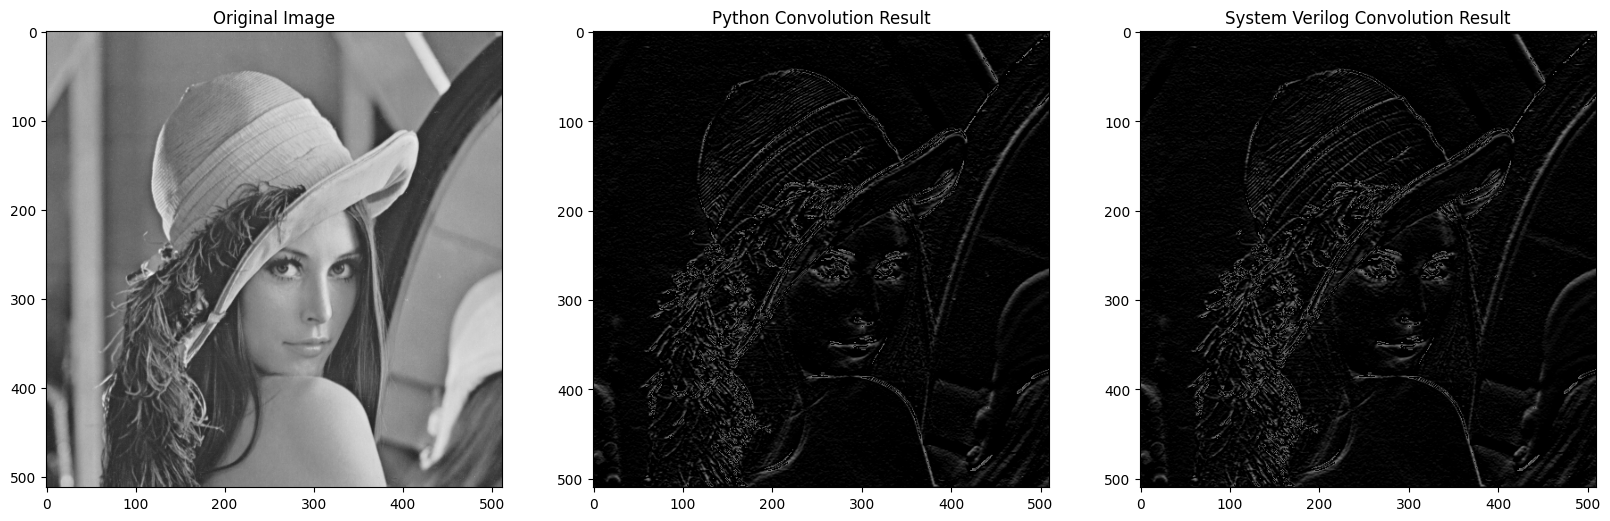

In [44]:
print("Разрешение исходного изображения: ", img.shape)
print("Разрешение полученного в Python изображения: ", result.shape)
print("Разрешение полученного в SV изображения: ", img_sv.shape)
plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray', vmin = 0, vmax = 255)
# plt.imshow(img[200:250,200:250], cmap='gray', vmin = 0, vmax = 255)

plt.subplot(1, 3, 2)
plt.title("Python Convolution Result")
plt.imshow(result, cmap='gray', vmin = 0, vmax = 255)
# plt.imshow(result[200:250,200:250], cmap='gray', vmin = 0, vmax = 255)

plt.subplot(1, 3, 3)
plt.title("System Verilog Convolution Result")
plt.imshow(img_sv, cmap='gray', vmin = 0, vmax = 255)
# plt.imshow(img_sv[200:250,200:250], cmap='gray', vmin = 0, vmax = 255)
plt.show()

In [45]:
mse = calculate_mse(result, img_sv)
print(mse)

0.9969088811995387
